In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
df = pd.read_csv('run_2026-04-24_08-11-35.csv')

df = df[df["name"].str.contains("mean|stddev")]
df = df.reset_index(drop=True)

N = [10, 20, 50, 80]
method_names = ["Kernel_Baseline", "Kernel_Precomp_Wavelets", 
    "FFT_Baseline", "FFT_Precomp_Wavelets",
    "Kernel_Biais_Method", "FFT_Biais_Method"]

time_means = [[] for _ in range(6)]
time_stds = [[] for _ in range(6)]

time_per_map_means = [[] for _ in range(6)]
time_per_map_stds = [[] for _ in range(6)]

memory_means = [[] for _ in range(6)]
memory_stds = [[] for _ in range(6)]

for i in range(6):
    time_means[i] = df.iloc[8*i:8*(i+1):2]["real_time"].tolist()
    time_stds[i] = df.iloc[8*i+1:8*(i+1):2]["real_time"].tolist()

    time_per_map_means[i] = df.iloc[8*i:8*(i+1):2]["Time_per_contamination_map"].tolist()
    time_per_map_stds[i] = df.iloc[8*i+1:8*(i+1):2]["Time_per_contamination_map"].tolist()

    memory_means[i] = df.iloc[8*i:8*(i+1):2]["Memory"].tolist()
    memory_stds[i] = df.iloc[8*i+1:8*(i+1):2]["Memory"].tolist()

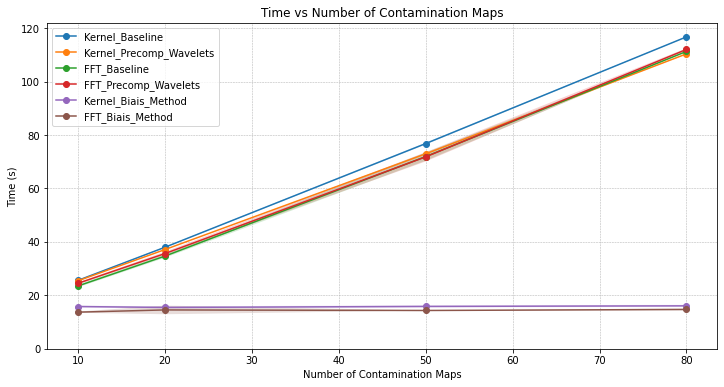

In [5]:
plt.figure(figsize=(12, 6))
for method_name, time_mean, time_std in zip(method_names, time_means, time_stds):
    time_mean = np.array(time_mean)
    time_std = np.array(time_std)

    plt.plot(
        N,
        time_mean, 
        label=method_name,
        marker='o'
    )

    plt.fill_between(
        N,
        time_mean - time_std,
        time_mean + time_std,
        alpha=0.2
    )

plt.xlabel('Number of Contamination Maps')
plt.ylabel('Time (s)')
plt.title('Time vs Number of Contamination Maps')
plt.legend()

plt.ylim(bottom=0)
plt.grid(True, which="both", ls="--", linewidth=0.5)

plt.show()

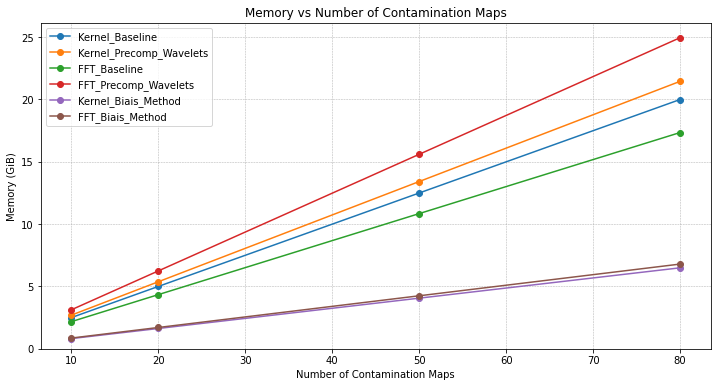

In [6]:
plt.figure(figsize=(12, 6))
for method_name, memory_mean, memory_std in zip(method_names, memory_means, memory_stds):
    memory_mean = np.array(memory_mean)/(1024**3) # convert to GiB
    memory_std = np.array(memory_std)/(1024**3) # convert to GiB

    plt.plot(
        N, 
        memory_mean, 
        label=method_name,
        marker='o'
    )

    plt.fill_between(
        N,
        memory_mean - memory_std,
        memory_mean + memory_std,
        alpha=0.2
    )

plt.xlabel('Number of Contamination Maps')
plt.ylabel('Memory (GiB)')
plt.title('Memory vs Number of Contamination Maps')
plt.legend()

plt.ylim(bottom=0)
plt.grid(True, which="both", ls="--", linewidth=0.5)

plt.show()

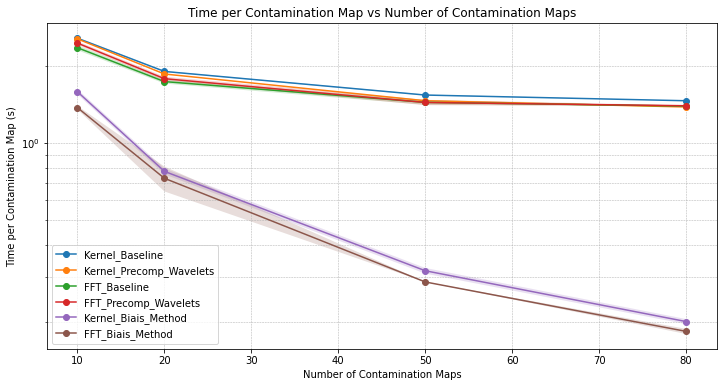

In [7]:
plt.figure(figsize=(12, 6))
for method_name, time_per_map_mean, time_per_map_std in zip(method_names, time_per_map_means, time_per_map_stds):
    time_per_map_mean = np.array(time_per_map_mean)
    time_per_map_std = np.array(time_per_map_std)

    plt.semilogy(
        N, 
        time_per_map_mean, 
        label=method_name,
        marker='o'
    )

    plt.fill_between(
        N,
        time_per_map_mean - time_per_map_std,
        time_per_map_mean + time_per_map_std,
        alpha=0.2
    )

plt.xlabel('Number of Contamination Maps')
plt.ylabel('Time per Contamination Map (s)')
plt.title('Time per Contamination Map vs Number of Contamination Maps')
plt.legend()

plt.grid(True, which="both", ls="--", linewidth=0.5)

plt.show()